In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
%pip install xgboost

In [10]:
from xgboost import XGBRegressor

In [11]:
#Step 2. Create a normal regression dataset

#Start with a simple relationship.

#Suppose:

#$$ Y = 3 + 2X_1 + 1.5X_2 - X_3 + \epsilon $$

#Generate 1,000 observations.
np.random.seed(42)

n = 1000

X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
X3 = np.random.normal(0, 1, n)

error = np.random.normal(0, 1, n)

Y = 3 + 2*X1 + 1.5*X2 - X3 + error

df = pd.DataFrame({
    "X1": X1,
    "X2": X2,
    "X3": X3,
    "Y": Y
})

df.head()

,X1,X2,X3,Y
0,0.496714,1.399355,-0.675178,4.859832
1,-0.138264,0.924634,-0.144519,3.394556
2,0.647689,0.059630,-0.792420,4.763637
3,1.523030,-0.646937,-0.307962,7.271304
4,-0.234153,0.698223,-1.893615,6.029196


In [12]:
#Step 3. Split the data
X = df[["X1", "X2", "X3"]]
y = df["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#80% training, 20% testing.

In [13]:
#Step 4. Create a function to compare models
def evaluate_models(X_train, X_test, y_train, y_test):

    models = {
        "OLS": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Huber": HuberRegressor(),
        "Random Forest": RandomForestRegressor(
            n_estimators=200, random_state=42
        ),
        "XGBoost": XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            random_state=42
        )
    }

    results = []

    for name, model in models.items():

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        mae = mean_absolute_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)

        results.append({
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

    return pd.DataFrame(results)

In [14]:
results = evaluate_models(
    X_train, X_test, y_train, y_test
)

results

,Model,RMSE,MAE,R2
0,OLS,1.036938,0.827121,0.876029
1,Ridge,1.037339,0.827542,0.875933
2,Huber,1.037429,0.828090,0.875911
3,Random Forest,1.228379,0.956959,0.826028
4,XGBoost,1.132448,0.897738,0.852140


In [15]:
#outlier generator
def create_outlier_data(
    outlier_percentage,
    seed=42
):

    np.random.seed(seed)

    n = 1000

    X1 = np.random.normal(0, 1, n)
    X2 = np.random.normal(0, 1, n)
    X3 = np.random.normal(0, 1, n)

    error = np.random.normal(0, 1, n)

    Y = (
        3
        + 2 * X1
        + 1.5 * X2
        - X3
        + error
    )

    number_of_outliers = int(
        outlier_percentage * n
    )

    indices = np.random.choice(
        n,
        size=number_of_outliers,
        replace=False
    )

    Y[indices] += np.random.normal(
        0,
        15,
        number_of_outliers
    )

    return pd.DataFrame({
        "X1": X1,
        "X2": X2,
        "X3": X3,
        "Y": Y
    })

In [16]:
#Experiment
def run_outlier_experiment(
    outlier_percentage,
    seed
):

    data = create_outlier_data(
        outlier_percentage
    )

    X = data[["X1", "X2", "X3"]]
    y = data["Y"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=seed
    )

    results = evaluate_models(
        X_train,
        X_test,
        y_train,
        y_test
    )

    results["Outlier_Percentage"] = (
        outlier_percentage * 100
    )

    results["Seed"] = seed

    return results

In [17]:
#Run 0%, 2%, 5%, 10%
outlier_levels = [
    0,
    0.02,
    0.05,
    0.10
]

all_results = []

for level in outlier_levels:

    for seed in range(10):

        results = run_outlier_experiment(
            level,
            seed
        )

        all_results.append(results)

outlier_repeated_results = pd.concat(
    all_results,
    ignore_index=True
)

outlier_repeated_results.head()

,Model,RMSE,MAE,R2,Outlier_Percentage,Seed
0,OLS,1.078885,0.869807,0.856530,0.0,0
1,Ridge,1.079177,0.869941,0.856453,0.0,0
2,Huber,1.078118,0.869171,0.856734,0.0,0
3,Random Forest,1.234056,0.989083,0.812293,0.0,0
4,XGBoost,1.153416,0.910591,0.836023,0.0,0


In [18]:
#Summary
outlier_summary = (
    outlier_repeated_results
    .groupby(
        ["Outlier_Percentage", "Model"]
    )["RMSE"]
    .mean()
    .reset_index()
)

outlier_summary

,Outlier_Percentage,Model,RMSE
0,0.0,Huber,1.046298
1,0.0,OLS,1.046290
2,0.0,Random Forest,1.214764
3,0.0,Ridge,1.046338
4,0.0,XGBoost,1.145818
5,2.0,Huber,2.425874
6,2.0,OLS,2.434032
7,2.0,Random Forest,2.611366
8,2.0,Ridge,2.434003
9,2.0,XGBoost,2.573664


In [19]:
#Save
outlier_summary.to_csv(
    "../results/tables/outlier_results.csv",
    index=False
)

<ipython-input-20-8624f610ad71>:24: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  plt.savefig(
<ipython-input-20-8624f610ad71>:24: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  plt.savefig(


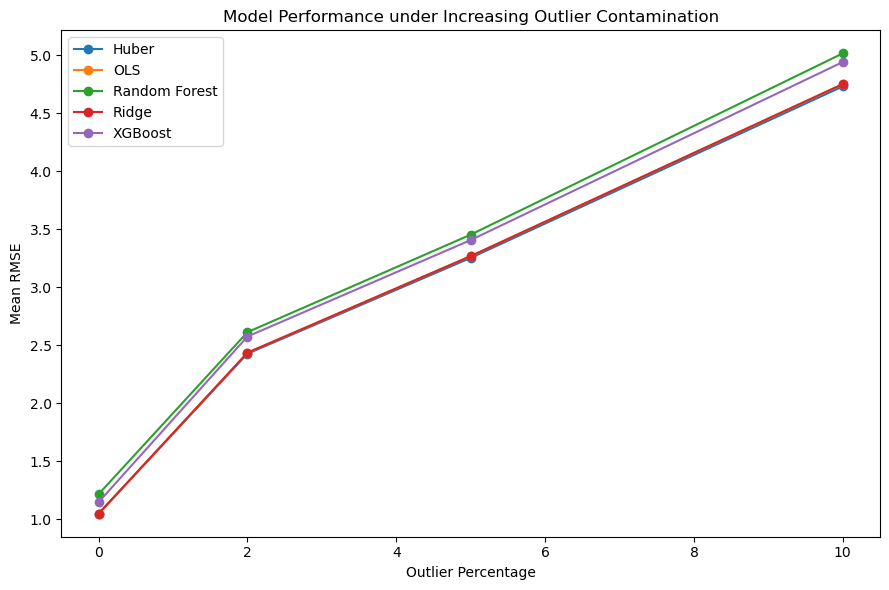

In [20]:
#Plot
plt.figure(figsize=(9, 6))

for model in outlier_summary["Model"].unique():

    model_data = outlier_summary[
        outlier_summary["Model"] == model
    ]

    plt.plot(
        model_data["Outlier_Percentage"],
        model_data["RMSE"],
        marker="o",
        label=model
    )

plt.xlabel("Outlier Percentage")
plt.ylabel("Mean RMSE")
plt.title("Model Performance under Increasing Outlier Contamination")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/outlier_robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()